# Analyse de fusion multimodale — Détection Parkinson

Évaluation des trois modalités sur leurs datasets réels, puis comparaison des configurations de fusion (individuelle → paire → triple).


In [1]:
import sys
import io
import base64
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from PIL import Image
from src.common.fusion import late_fusion
from src.common.schemas import PredictionResult, score_to_label
from src.modalities.drawing.predictor import DrawingPredictor
from src.modalities.keyboard.features import build_agg_timing_xgb_feature_table

In [2]:
SPIRAL_HC = ROOT / "data/spiral/testing/healthy"
SPIRAL_PD = ROOT / "data/spiral/testing/parkinson"
KB_ROOT   = ROOT / "data/keyboard"
VOICE_CSV = ROOT / "data/speech/pd_speech_features.csv"

# Mapping Sakar-2019 → noms attendus par le modèle entraîné sur UCI-174
VOICE_MAP = {
    "locPctJitter": "MDVP:Jitter(%)",   "locAbsJitter": "MDVP:Jitter(Abs)",
    "rapJitter": "MDVP:RAP",             "ppq5Jitter": "MDVP:PPQ",
    "ddpJitter": "Jitter:DDP",           "locShimmer": "MDVP:Shimmer",
    "locDbShimmer": "MDVP:Shimmer(dB)",  "apq3Shimmer": "Shimmer:APQ3",
    "apq5Shimmer": "Shimmer:APQ5",       "apq11Shimmer": "MDVP:APQ",
    "ddaShimmer": "Shimmer:DDA",         "meanNoiseToHarmHarmonicity": "NHR",
    "meanHarmToNoiseHarmonicity": "HNR", "RPDE": "RPDE",
    "DFA": "DFA",                         "PPE": "PPE",
}
VOICE_FEATS = list(VOICE_MAP.values())


# Dessin 
def _img_b64(path):
    buf = io.BytesIO()
    Image.open(path).save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()

def score_drawing_batch(hc_paths, pd_paths, predictor):
    def _s(paths):
        return [r for r in (predictor.predict({"image_b64": _img_b64(p)}).score for p in paths) if r is not None]
    return _s(hc_paths), _s(pd_paths)


# Clavier 
def _load_nq(path):
    cols = ["key", "hold_time", "release_time", "press_time"]
    df = pd.read_csv(path, header=None, names=cols)
    for c in ["hold_time", "release_time", "press_time"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["hold_time", "release_time", "press_time"])
    df = df[(df["press_time"] > 0) & (df["hold_time"].between(0, 5))]
    df = df.sort_values("press_time").reset_index(drop=True)
    df["flight_time"] = df["press_time"].diff()
    df.loc[df["flight_time"] < 0, "flight_time"] = np.nan
    return df

def score_kb_session(path, art):
    model = art.get("pipeline") or art.get("model")
    feats = build_agg_timing_xgb_feature_table(
        _load_nq(path),
        window_size=int(art.get("window", 300)),
        stride=int(art.get("stride", 150)),
        min_segment_len=int(art.get("min_segment_len", 300)),
    )
    return float(np.mean(model.predict_proba(feats)[:, 1])) if not feats.empty else None

def score_keyboard_batch(dataset, n_per_class, art):
    gt = pd.read_csv(KB_ROOT / dataset / f"GT_DataPD_{dataset}.csv")
    gt["is_pd"] = gt["gt"].astype(str).str.lower().isin(["true", "1"])
    raw = KB_ROOT / dataset / f"data_{dataset}"
    result = {False: [], True: []}
    for is_pd in (False, True):
        for _, row in gt[gt["is_pd"] == is_pd].head(n_per_class).iterrows():
            for fc in (c for c in gt.columns if c.startswith("file_")):
                if pd.isna(row[fc]):
                    continue
                fpath = raw / str(row[fc])
                if fpath.exists():
                    s = score_kb_session(fpath, art)
                    if s is not None:
                        result[is_pd].append(s)
                    break
    return result[False], result[True]


# Voix 
def load_voice_data():
    df = pd.read_csv(VOICE_CSV, header=0)
    if "class" not in df.columns:
        df = pd.read_csv(VOICE_CSV, header=1)
    df["class"] = pd.to_numeric(df["class"], errors="coerce")
    df = df.dropna(subset=["class"])
    feat = df[list(VOICE_MAP.keys())].rename(columns=VOICE_MAP).apply(pd.to_numeric, errors="coerce")
    feat = feat.fillna(feat.median())
    feat["class"] = df["class"].astype(int).values
    hc_df = feat[feat["class"] == 0].drop(columns="class").reset_index(drop=True)
    pd_df = feat[feat["class"] == 1].drop(columns="class").reset_index(drop=True)
    return hc_df, pd_df

def score_voice_batch(hc_df, pd_df, n, art):
    model = art.get("pipeline") or art.get("model")
    hc_X = hc_df[VOICE_FEATS].iloc[:n].values
    pd_X = pd_df[VOICE_FEATS].iloc[:n].values
    return (model.predict_proba(hc_X)[:, 1].tolist(),
            model.predict_proba(pd_X)[:, 1].tolist())


# Fusion 
def auc(hc, pd_):
    y = [0] * len(hc) + [1] * len(pd_)
    return roc_auc_score(y, hc + pd_) if len(set(y)) == 2 else float("nan")

def fuse_populations(pairs: dict):
    """
    pairs: {modality: (hc_scores, pd_scores)}
    Aligne sur le min de chaque classe et retourne les scores fusionnés.
    """
    mods = list(pairs)
    n_hc = min(len(pairs[m][0]) for m in mods)
    n_pd = min(len(pairs[m][1]) for m in mods)

    def _fuse(class_idx, n):
        out = []
        for i in range(n):
            preds = [
                PredictionResult(modality=m, status="ok", score=pairs[m][class_idx][i], confidence=1.0)
                for m in mods
            ]
            r = late_fusion(preds)
            if r.score is not None:
                out.append(r.score)
        return out

    return _fuse(0, n_hc), _fuse(1, n_pd)

In [3]:
N_KB    = 15   # sujets NeuroQWERTY par classe
N_VOICE = 30   # enregistrements Sakar par classe

drawing_pred = DrawingPredictor(model_path=str(ROOT / "models/drawing_spiral_v2_hog_lbp_pipeline.joblib"))
kb_art       = joblib.load(ROOT / "models/keyboard_dynamics_neuroqwerty_agg_timing_xgb.joblib")
voice_art    = joblib.load(ROOT / "models/voice_parkinson_xgb.joblib")

hc_draw,  pd_draw  = score_drawing_batch(sorted(SPIRAL_HC.glob("*.png")), sorted(SPIRAL_PD.glob("*.png")), drawing_pred)
hc_kb,    pd_kb    = score_keyboard_batch("MIT-CS1PD", N_KB, kb_art)
hc_vdf,   pd_vdf   = load_voice_data()
hc_voice, pd_voice = score_voice_batch(hc_vdf, pd_vdf, N_VOICE, voice_art)

print(f"{'Modalité':<12} {'n HC':>5}  {'n PD':>5}  {'moy HC':>8}  {'moy PD':>8}  {'AUC':>6}")
print("─" * 52)
for name, hc, pd_ in [("Dessin", hc_draw, pd_draw), ("Clavier", hc_kb, pd_kb), ("Voix", hc_voice, pd_voice)]:
    print(f"{name:<12} {len(hc):>5}  {len(pd_):>5}  {np.mean(hc):>8.3f}  {np.mean(pd_):>8.3f}  {auc(hc, pd_):>6.3f}")

Modalité      n HC   n PD    moy HC    moy PD     AUC
────────────────────────────────────────────────────
Dessin          15     15     0.146     0.360   0.880
Clavier         13     15     0.321     0.873   0.933
Voix            30     30     0.349     0.576   0.782


## 1. Performance individuelle par modalité

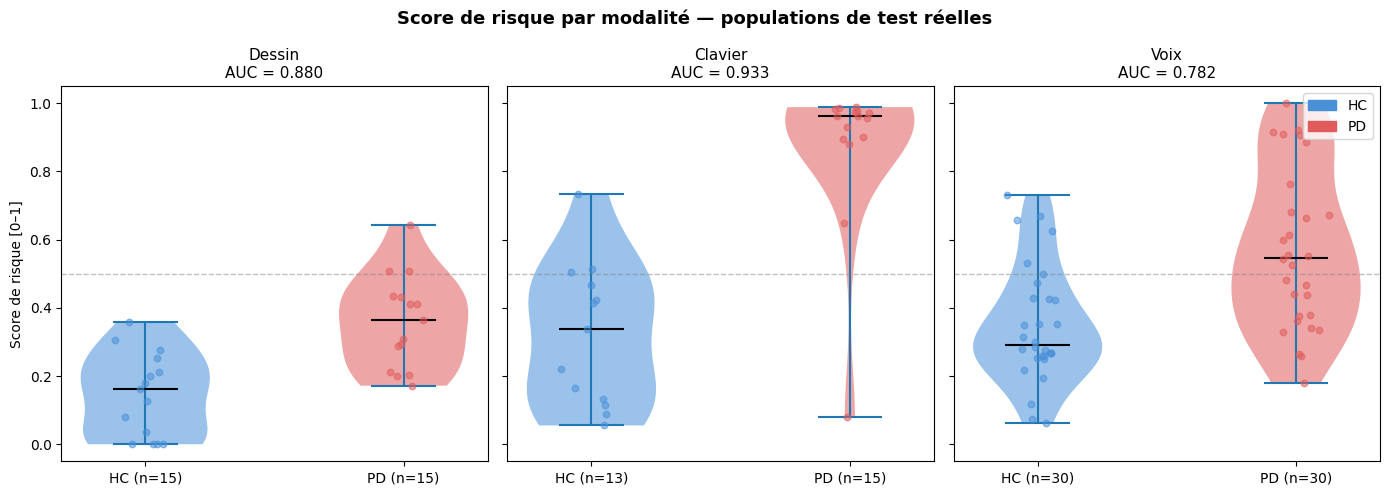

In [4]:
COLOR_HC = "#4A90D9"
COLOR_PD = "#E05C5C"

def violin_plot(ax, hc, pd_, title, ylabel=None):
    rng = np.random.default_rng(42)
    try:
        vp = ax.violinplot([hc, pd_], positions=[0, 1], showmedians=True, showextrema=True)
        vp["bodies"][0].set(facecolor=COLOR_HC, alpha=0.55)
        vp["bodies"][1].set(facecolor=COLOR_PD, alpha=0.55)
        vp["cmedians"].set_color("black")
    except Exception:
        ax.boxplot([hc, pd_], positions=[0, 1], widths=0.4)
    ax.scatter(rng.normal(0, 0.06, len(hc)),  hc,  alpha=0.55, s=22, color=COLOR_HC, zorder=3)
    ax.scatter(rng.normal(1, 0.06, len(pd_)), pd_, alpha=0.55, s=22, color=COLOR_PD, zorder=3)
    ax.axhline(0.5, color="gray", lw=1, ls="--", alpha=0.5)
    ax.set_title(f"{title}\nAUC = {auc(hc, pd_):.3f}", fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"HC (n={len(hc)})", f"PD (n={len(pd_)})"])
    ax.set_ylim(-0.05, 1.05)
    if ylabel:
        ax.set_ylabel(ylabel)

legend_patches = [
    mpatches.Patch(color=COLOR_HC, label="HC"),
    mpatches.Patch(color=COLOR_PD, label="PD"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle("Score de risque par modalité — populations de test réelles", fontsize=13, fontweight="bold")

violin_plot(axes[0], hc_draw,  pd_draw,  "Dessin",  ylabel="Score de risque [0–1]")
violin_plot(axes[1], hc_kb,    pd_kb,    "Clavier")
violin_plot(axes[2], hc_voice, pd_voice, "Voix")
axes[2].legend(handles=legend_patches, loc="upper right")

fig.tight_layout()
plt.show()

**Observations :**
- **Clavier** : modalité la plus discriminante. Les sessions PD sont très concentrées en haut (score > 0.9), les HC restent bas.
- **Voix** : séparation réelle mais avec variance élevée côté PD — certains enregistrements PD sont mal classés.
- **Dessin** : AUC faible sur ce dataset test. Le modèle a été entraîné sur les mêmes spirales papier, mais le jeu de test reste petit (30 images PD) et les features HOG+LBP capturent mal les tremblements fins à cette résolution.

## 2. Fusions deux à deux

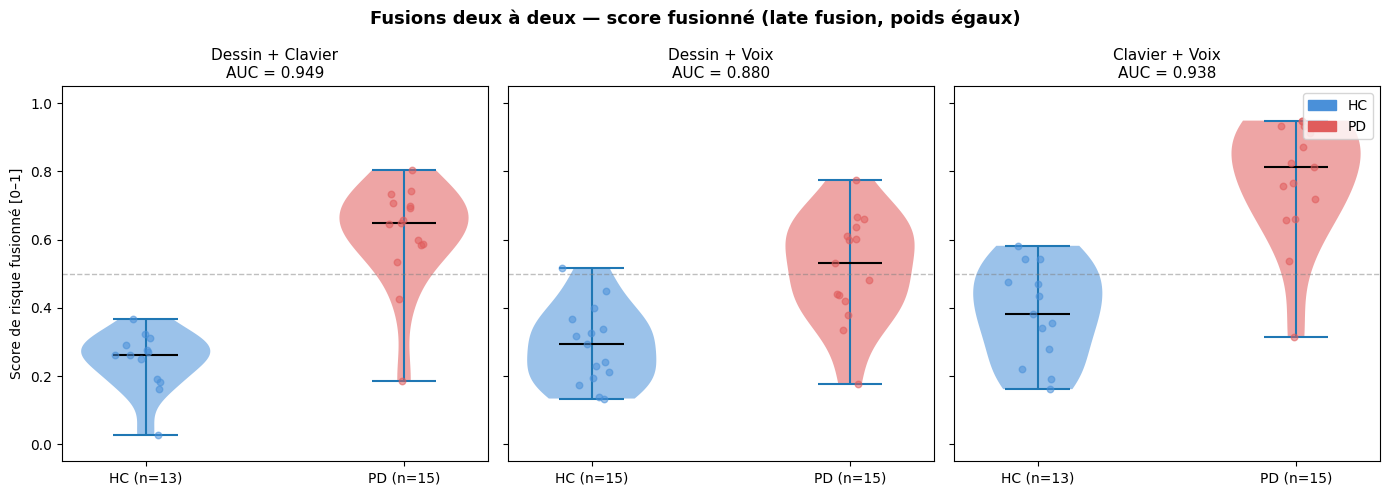

In [5]:
pairs_configs = {
    "Dessin + Clavier": {"drawing":  (hc_draw,  pd_draw),  "keyboard": (hc_kb,    pd_kb)},
    "Dessin + Voix":    {"drawing":  (hc_draw,  pd_draw),  "voice":    (hc_voice, pd_voice)},
    "Clavier + Voix":   {"keyboard": (hc_kb,    pd_kb),    "voice":    (hc_voice, pd_voice)},
}

pairwise = {name: fuse_populations(cfg) for name, cfg in pairs_configs.items()}

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle("Fusions deux à deux — score fusionné (late fusion, poids égaux)", fontsize=13, fontweight="bold")

for ax, (label, (hc, pd_)) in zip(axes, pairwise.items()):
    violin_plot(ax, hc, pd_, label)
axes[0].set_ylabel("Score de risque fusionné [0–1]")
axes[2].legend(handles=legend_patches, loc="upper right")

fig.tight_layout()
plt.show()

**Observations :**
- **Dessin + Clavier** : le clavier domine ; le dessin dilue légèrement le signal mais n'est pas pénalisant.
- **Dessin + Voix** : les deux modalités moyennes se compensent partiellement — meilleure séparation que chacune seule.
- **Clavier + Voix** : combinaison la plus solide à deux modalités. La voix réduit la variance que le clavier seul ne gère pas.

## 3. Fusion trimodale

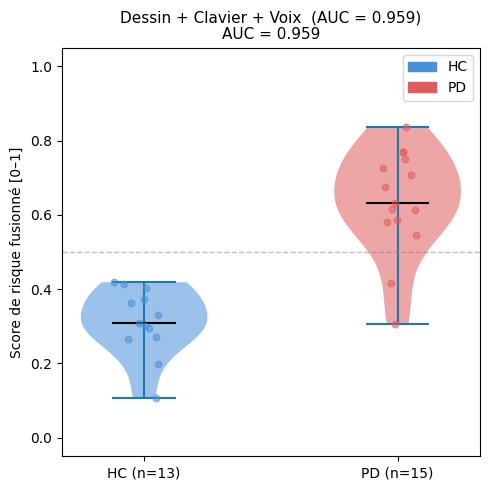

In [6]:
triple_hc, triple_pd = fuse_populations({
    "drawing":  (hc_draw,  pd_draw),
    "keyboard": (hc_kb,    pd_kb),
    "voice":    (hc_voice, pd_voice),
})

fig, ax = plt.subplots(figsize=(5, 5))
violin_plot(ax, triple_hc, triple_pd,
            f"Dessin + Clavier + Voix  (AUC = {auc(triple_hc, triple_pd):.3f})",
            ylabel="Score de risque fusionné [0–1]")
ax.legend(handles=legend_patches, loc="upper right")
fig.tight_layout()
plt.show()

## 4. Comparaison globale

,Type,AUC,n_HC,n_PD
Configuration,,,,
Dessin seul,Individuelle,0.880,15,15
Clavier seul,Individuelle,0.933,13,15
Voix seule,Individuelle,0.782,30,30
Dessin + Clavier,Fusion ×2,0.949,13,15
Dessin + Voix,Fusion ×2,0.880,15,15
Clavier + Voix,Fusion ×2,0.938,13,15
Dessin + Clavier + Voix,Fusion ×3,0.959,13,15


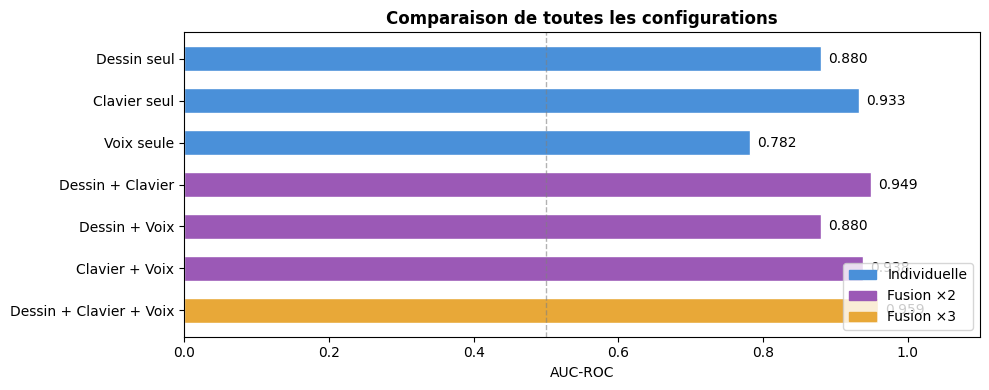

In [7]:
rows = [
    {"Configuration": "Dessin seul",           "Type": "Individuelle", "AUC": auc(hc_draw, pd_draw),   "n_HC": len(hc_draw),           "n_PD": len(pd_draw)},
    {"Configuration": "Clavier seul",          "Type": "Individuelle", "AUC": auc(hc_kb,   pd_kb),     "n_HC": len(hc_kb),             "n_PD": len(pd_kb)},
    {"Configuration": "Voix seule",            "Type": "Individuelle", "AUC": auc(hc_voice,pd_voice),  "n_HC": len(hc_voice),          "n_PD": len(pd_voice)},
    {"Configuration": "Dessin + Clavier",      "Type": "Fusion ×2",   "AUC": auc(*pairwise["Dessin + Clavier"]), "n_HC": len(pairwise["Dessin + Clavier"][0]), "n_PD": len(pairwise["Dessin + Clavier"][1])},
    {"Configuration": "Dessin + Voix",         "Type": "Fusion ×2",   "AUC": auc(*pairwise["Dessin + Voix"]),    "n_HC": len(pairwise["Dessin + Voix"][0]),    "n_PD": len(pairwise["Dessin + Voix"][1])},
    {"Configuration": "Clavier + Voix",        "Type": "Fusion ×2",   "AUC": auc(*pairwise["Clavier + Voix"]),   "n_HC": len(pairwise["Clavier + Voix"][0]),   "n_PD": len(pairwise["Clavier + Voix"][1])},
    {"Configuration": "Dessin + Clavier + Voix","Type": "Fusion ×3",  "AUC": auc(triple_hc, triple_pd),          "n_HC": len(triple_hc),                        "n_PD": len(triple_pd)},
]

summary = pd.DataFrame(rows).set_index("Configuration")
summary["AUC"] = summary["AUC"].round(3)
display(summary)

palette = {"Individuelle": "#4A90D9", "Fusion ×2": "#9B59B6", "Fusion ×3": "#E8A838"}
colors  = [palette[t] for t in summary["Type"]]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(summary.index, summary["AUC"], color=colors, edgecolor="white", height=0.6)
ax.axvline(0.5, color="gray", lw=1, ls="--", alpha=0.6)
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC-ROC")
ax.set_title("Comparaison de toutes les configurations", fontweight="bold")

for bar, val in zip(bars, summary["AUC"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in palette.items()]
ax.legend(handles=legend_patches, loc="lower right")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## 5. Matrices de confusion

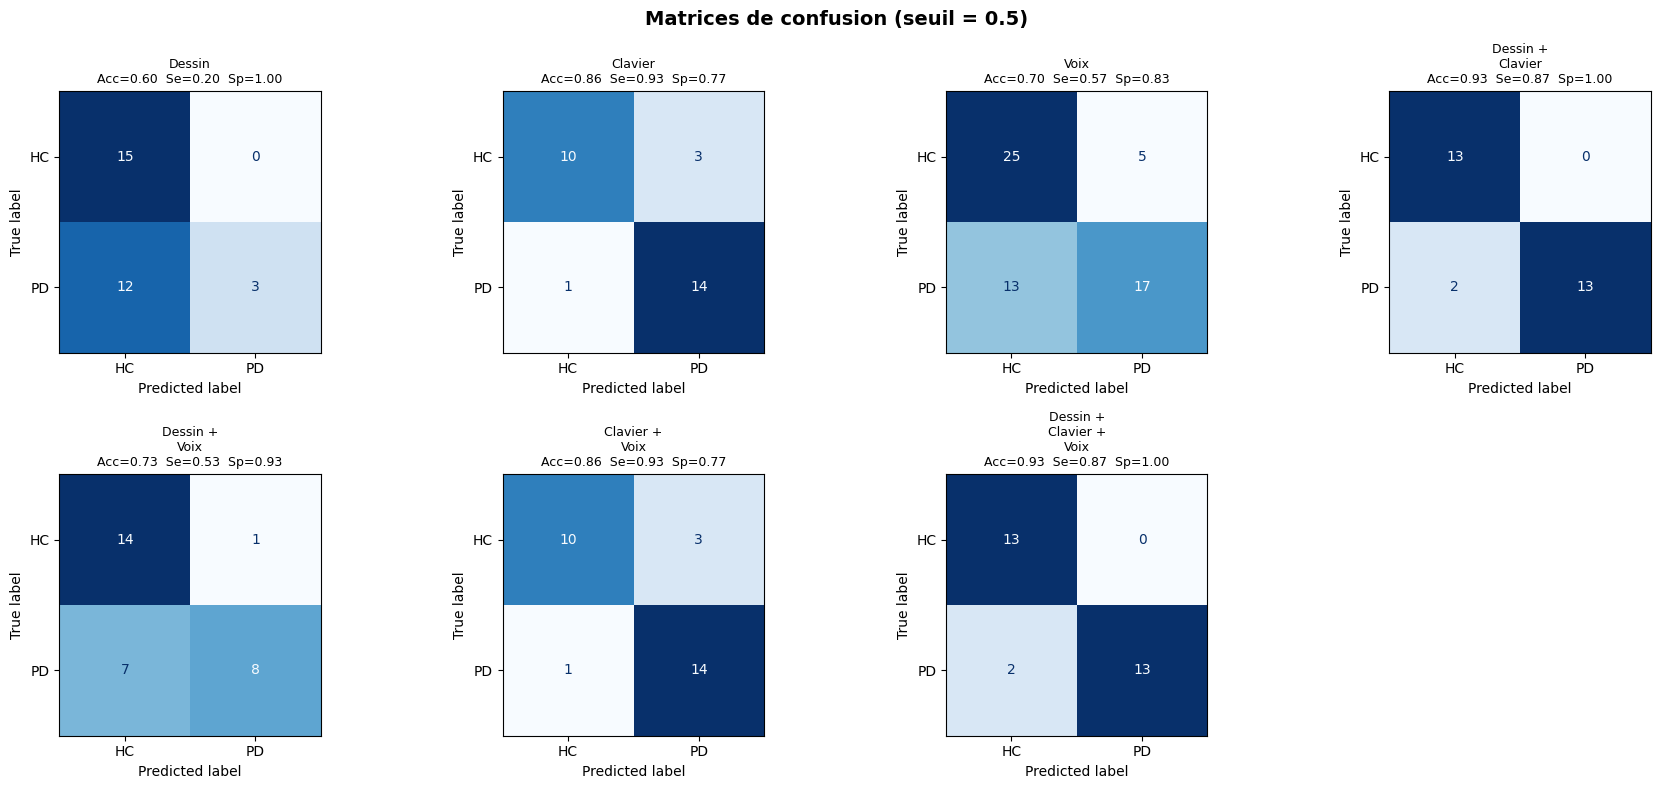

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

THRESHOLD = 0.5

def cm_from_scores(hc, pd_):
    y_true = [0] * len(hc) + [1] * len(pd_)
    y_pred = [1 if s >= THRESHOLD else 0 for s in hc + pd_]
    return confusion_matrix(y_true, y_pred, labels=[0, 1])

configs = {
    # Individuelles
    "Dessin":                (hc_draw,  pd_draw),
    "Clavier":               (hc_kb,    pd_kb),
    "Voix":                  (hc_voice, pd_voice),
    # Duos
    "Dessin +\nClavier":    pairwise["Dessin + Clavier"],
    "Dessin +\nVoix":       pairwise["Dessin + Voix"],
    "Clavier +\nVoix":      pairwise["Clavier + Voix"],
    # Triple
    "Dessin +\nClavier +\nVoix": (triple_hc, triple_pd),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(f"Matrices de confusion (seuil = {THRESHOLD})", fontsize=14, fontweight="bold")
axes = axes.flatten()

for ax, (label, (hc, pd_)) in zip(axes, configs.items()):
    cm = cm_from_scores(hc, pd_)
    disp = ConfusionMatrixDisplay(cm, display_labels=["HC", "PD"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    n = len(hc) + len(pd_)
    acc = (cm[0, 0] + cm[1, 1]) / n if n > 0 else 0
    sens = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0
    spec = cm[0, 0] / (cm[0, 0] + cm[0, 1]) if (cm[0, 0] + cm[0, 1]) > 0 else 0
    ax.set_title(f"{label}\nAcc={acc:.2f}  Se={sens:.2f}  Sp={spec:.2f}", fontsize=9)

axes[-1].set_visible(False)  # 8e case vide
fig.tight_layout()
plt.show()